In [ ]:
from astropy.io import ascii
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from scipy.interpolate import CubicSpline

### Problem 1

In [74]:
filename='MWvrot_BovyRix_RAR.dat'
if not os.path.isfile(filename):
 MW_rot= ascii.read('https://burro.case.edu/Academics/Astr323/HW/HW4/'+filename)
 ascii.write(MW_rot, filename, overwrite=True)
else:
 MW_rot=ascii.read(filename)

In [75]:
R = MW_rot['R']
V = MW_rot['V']

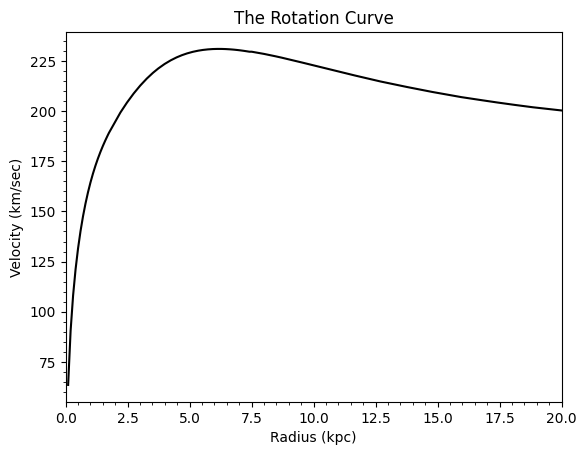

In [76]:
plt.plot(R, V, color = 'k', lw = 1.5)
plt.xlim(0,20)
plt.xlabel("Radius (kpc)")
plt.ylabel("Velocity (km/sec)")
plt.title("The Rotation Curve")
plt.minorticks_on()

In [77]:
dVdR = np.gradient(V, R)
A = -0.5 * (dVdR - V/R)
B = -0.5 * (dVdR + V/R)
kappa = np.sqrt(-4*B*(A-B))
ang_freq = V/R

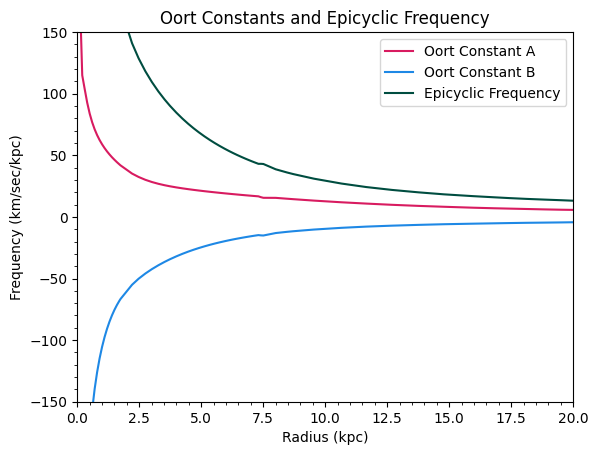

In [78]:
plt.plot(R, A, label = "Oort Constant A", color = '#D81B60', lw = 1.5)
plt.plot(R, B, label = "Oort Constant B", color = '#1E88E5', lw = 1.5)
plt.plot(R, kappa, label = "Epicyclic Frequency", color = '#004D40', lw = 1.5)
plt.ylim(-150,150)
plt.xlim(0,20)
plt.xlabel("Radius (kpc)")
plt.ylabel("Frequency (km/sec/kpc)")
plt.title("Oort Constants and Epicyclic Frequency")
plt.minorticks_on()
plt.legend()

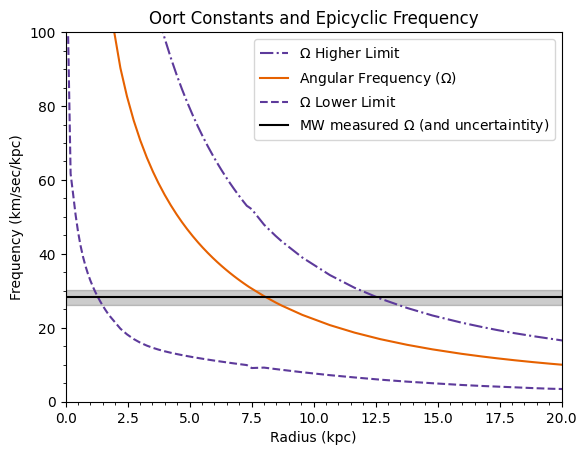

In [79]:
plt.plot(R, ang_freq + kappa/2, label = r"$\Omega$ Higher Limit", color = '#5D3A9B', ls = '-.')
plt.plot(R, ang_freq, label = r"Angular Frequency ($\Omega$)", color = '#E66100', ls = '-')
plt.plot(R, ang_freq - kappa/2, label = r"$\Omega$ Lower Limit", color = '#5D3A9B', ls = '--')
#plt.axhline(28.2+2.1, alpha = 0.5, color = 'k', label = "MW spiral arms speed")
plt.axhline(28.2, color = 'k', label = r"MW measured $\Omega$ (and uncertaintity)")
#plt.axhline(28.2-2.1, alpha = 0.5, color = 'k', label = "MW spiral arms speed")
plt.axhspan(28.2-2.1, 28.2+2.1, color='k', alpha=0.2)
plt.ylim(0,100)
plt.xlim(0,20)
plt.xlabel("Radius (kpc)")
plt.ylabel("Frequency (km/sec/kpc)")
plt.title("Oort Constants and Epicyclic Frequency")
plt.minorticks_on()
plt.legend()

In [80]:
from scipy.interpolate import CubicSpline
v_spline = CubicSpline(R, V)
dvdr_spline = v_spline.derivative(nu=1)
x=np.linspace(np.min(R),np.max(R),1000)
print('The Rotation Curve has a value of {:.2f} at R=8.2'.format(v_spline(8.2)))
print('The Derivative of the angular frequency has a value of {:.2f} at R=8.2'.format(dvdr_spline(8.2)))


The Rotation Curve has a value of 227.98 at R=8.2
The Derivative of the angular frequency has a value of -2.50 at R=8.2


In [81]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline

# -------------------------------------------------------------
# 1. Load data
# -------------------------------------------------------------
# Cubic spline for smooth V(R) and derivative
V_spline = CubicSpline(R, V, bc_type='natural')
dVdR_spline = V_spline.derivative(1)

# -------------------------------------------------------------
# 2. Solar circle
# -------------------------------------------------------------
Rsun = 8.2  # kpc

V_sun = V_spline(Rsun)
dVdR_sun = dVdR_spline(Rsun)

# Oort constants
A = -0.5 * (dVdR_sun - V_sun / Rsun)
B = -0.5 * (dVdR_sun + V_sun / Rsun)

# Epicyclic frequency
kappa_sun = np.sqrt(2 * V_sun / Rsun * (dVdR_sun + V_sun / Rsun))

print("------ Solar Circle Values ------")
print(f"Oort A = {A:.3f} km/s/kpc")
print(f"Oort B = {B:.3f} km/s/kpc")
print(f"Epicyclic frequency κ = {kappa_sun:.3f} km/s/kpc")

# -------------------------------------------------------------
# 3. Resonances
# -------------------------------------------------------------
Omega = lambda R: V_spline(R) / R
kappa = lambda R: np.sqrt(2 * V_spline(R)/R * (dVdR_spline(R) + V_spline(R)/R))

Omega_p = 28.0  # km/s/kpc, example pattern speed

def resonance_root(func, Rmin, Rmax, N=4000):
    Rvals = np.linspace(Rmin, Rmax, N)
    fvals = func(Rvals)
    idx = np.where(np.diff(np.sign(fvals)))[0]
    if len(idx) == 0:
        return None
    return Rvals[idx[0]]

ILR = resonance_root(lambda R: Omega(R) - kappa(R)/2 - Omega_p, 0.5, 20)
CR  = resonance_root(lambda R: Omega(R) - Omega_p, 0.5, 20)
OLR = resonance_root(lambda R: Omega(R) + kappa(R)/2 - Omega_p, 0.5, 20)

dist_from_CR = abs(Rsun - CR) if CR is not None else None

print("\n------ Resonance Radii ------")
print(f"ILR = {ILR:.3f} kpc")
print(f"CR  = {CR:.3f} kpc")
print(f"OLR = {OLR:.3f} kpc")
print(f"Distance of Sun from CR = {dist_from_CR:.3f} kpc")


------ Solar Circle Values ------
Oort A = 15.150 km/s/kpc
Oort B = -12.653 km/s/kpc
Epicyclic frequency κ = 37.512 km/s/kpc

------ Resonance Radii ------
ILR = 1.324 kpc
CR  = 8.146 kpc
OLR = 12.642 kpc
Distance of Sun from CR = 0.054 kpc


#### Problem 2

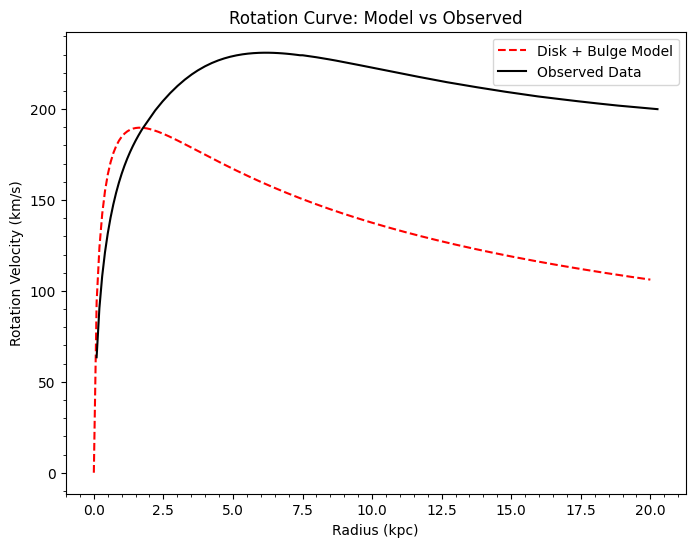

In [82]:
# Constants
G = 4.302e-6  # Gravitational constant in kpc * M_sun^-1 * (km/s)^2

# Given parameters for disk and bulge models
M_disk = 4.8e10  # Disk mass in solar masses
h_R = 2.5  # Disk scale length in kpc
M_bulge = 1.6e10  # Bulge mass in solar masses
a = 0.995  # Bulge scale radius in kpc

def V_disk(r):
    return np.sqrt(G * M_disk * r / (r + h_R)**2)

def V_bulge(r):
    return np.sqrt(G * M_bulge * r / (r + a)**2)

radii = np.linspace(0, 20, 200)

V_total = np.sqrt(V_disk(radii)**2 + V_bulge(radii)**2)

observed_radii = R
observed_velocities = V


plt.figure(figsize=(8, 6))
plt.plot(radii, V_total, label='Disk + Bulge Model', color='red', linestyle='--')
plt.plot(observed_radii, observed_velocities, label='Observed Data', color='black')
plt.xlabel('Radius (kpc)')
plt.ylabel('Rotation Velocity (km/s)')
plt.title('Rotation Curve: Model vs Observed')
plt.minorticks_on()
plt.legend()
plt.show()


C:\Users\bhoom\AppData\Local\Temp\ipykernel_40564\2971139725.py:35: RuntimeWarning: invalid value encountered in multiply
  term = i0(y)*k0(y) - i1(y)*k1(y)
C:\Users\bhoom\AppData\Local\Temp\ipykernel_40564\2971139725.py:43: RuntimeWarning: divide by zero encountered in divide
  (1 - (r_h/R)*np.arctan(R/r_h)) )
C:\Users\bhoom\AppData\Local\Temp\ipykernel_40564\2971139725.py:43: RuntimeWarning: invalid value encountered in multiply
  (1 - (r_h/R)*np.arctan(R/r_h)) )


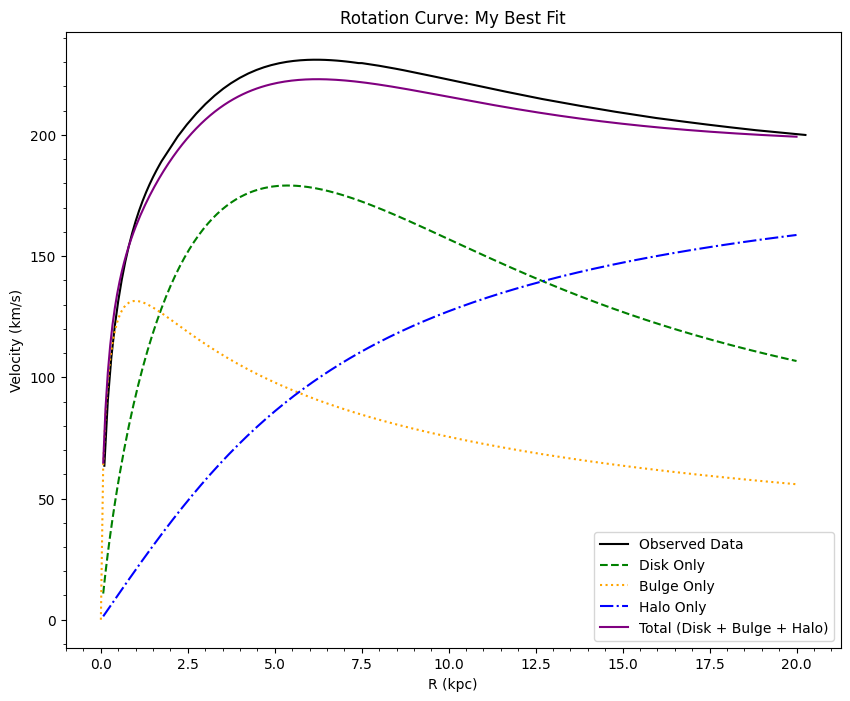

=== Velocities at Solar Radius (8 kpc) ===
Disk:  169.7 km/s
Bulge: 82.5 km/s
Halo:  114.5 km/s
Total: 220.7 km/s


In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0, k0, i1, k1

# Constants
G = 4.302e-6  # kpc * M_sun^-1 * (km/s)^2

# Disk parameters
h_R = 2.5  # kpc
Sigma_Rsun = 50  # M_sun/pc^2 at R=8 kpc
R_sun = 8.0  # kpc

# Convert surface density to central Sigma0
# Sigma(R) = Sigma0 * exp(-R/hR)
Sigma0 = Sigma_Rsun * np.exp(R_sun / h_R)   # M_sun/pc^2
Sigma0_kpc2 = Sigma0 * 1e6                  # convert to M_sun/kpc^2

# Bulge parameters
M_bulge = 1.6e10      # M_sun
a = 0.995             # Hernquist scale radius (kpc)

# --- Halo parameters (change manually here)
rho_0 = 0.024    # M_sun/pc^3 (will be converted properly below)
r_h = 5.5      # kpc

# Convert rho0 to M_sun/kpc^3
rho0_kpc3 = rho_0 * 1e9

# -----------------------------
#   Rotation Curve Functions
# -----------------------------

def V_disk(R):
    y = R / (2*h_R)
    term = i0(y)*k0(y) - i1(y)*k1(y)
    return np.sqrt(4*np.pi*G*Sigma0_kpc2*h_R * y**2 * term)

def V_bulge(R):
    return np.sqrt( G * M_bulge * R / (R + a)**2 )

def V_halo(R):
    return np.sqrt( 4*np.pi*G*rho0_kpc3*r_h**2 *
                   (1 - (r_h/R)*np.arctan(R/r_h)) )

def V_total(R):
    return np.sqrt(V_disk(R)**2 + V_bulge(R)**2 + V_halo(R)**2)


# -----------------------------
#   Plot Rotation Curve
# -----------------------------
radii = np.linspace(0, 20, 300)

Vd = V_disk(radii)
Vb = V_bulge(radii)
Vh = V_halo(radii)
Vt = V_total(radii)

plt.figure(figsize=(10,8))

plt.plot(R, V, label='Observed Data', color='black', linestyle='-')
plt.plot(radii, Vd, label='Disk Only', color='green', linestyle='--')
plt.plot(radii, Vb, label='Bulge Only', color='orange', linestyle=':')
plt.plot(radii, Vh, label='Halo Only', color='blue', linestyle='-.')
plt.plot(radii, Vt, label='Total (Disk + Bulge + Halo)', color='purple', linestyle='-')

plt.xlabel("R (kpc)")
plt.ylabel("Velocity (km/s)")
plt.title("Rotation Curve: My Best Fit")
plt.minorticks_on()
plt.legend()
plt.show()

# Print solar radius numbers
print("=== Velocities at Solar Radius (8 kpc) ===")
print(f"Disk:  {V_disk(R_sun):.1f} km/s")
print(f"Bulge: {V_bulge(R_sun):.1f} km/s")
print(f"Halo:  {V_halo(R_sun):.1f} km/s")
print(f"Total: {V_total(R_sun):.1f} km/s")


#### Problem 3

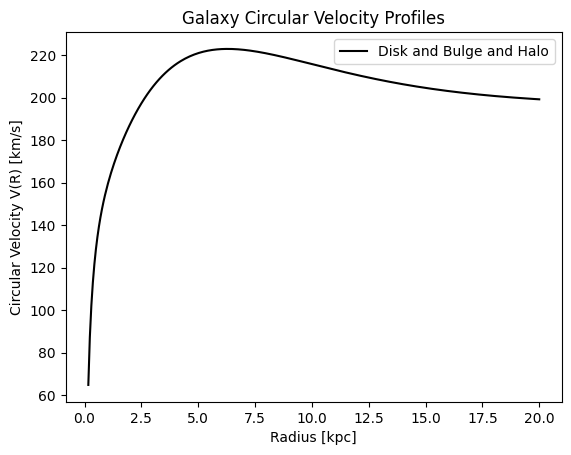

In [84]:
# Example radius array
R_prob3 = np.linspace(0.1, 20, 300)  # kpc

# Example component velocities (replace with your model!)
V_disk = Vd        # km/s, just as example
V_bulge = Vb          # km/s
V_halo = Vh          # km/s

# Total velocities
V_tot_with_bulge = np.sqrt(V_disk**2 + V_bulge**2 + V_halo**2)
V_tot_no_bulge = np.sqrt(V_disk**2 + V_halo**2)

plt.plot(R_prob3, V_tot_with_bulge, label='Disk and Bulge and Halo', color = 'black')
plt.xlabel('Radius [kpc]')
plt.ylabel('Circular Velocity V(R) [km/s]')
plt.title('Galaxy Circular Velocity Profiles')
plt.legend()

plt.show()


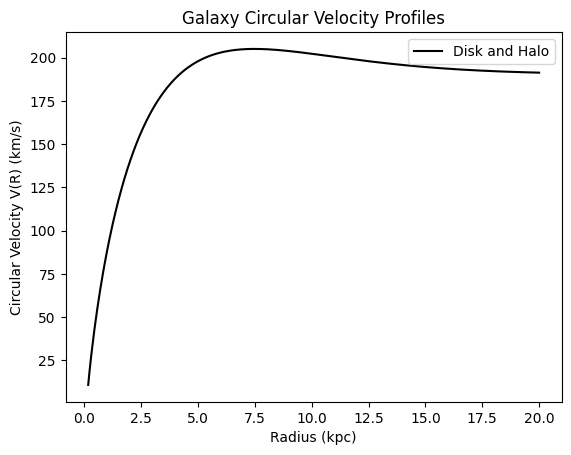

In [85]:
V_tot_no_bulge = np.sqrt(V_disk**2 + V_halo**2)

plt.plot(R_prob3, V_tot_no_bulge, label='Disk and Halo', color = 'black')
plt.xlabel('Radius (kpc)')
plt.ylabel('Circular Velocity V(R) (km/s)')
plt.title('Galaxy Circular Velocity Profiles')
plt.legend()
plt.show()


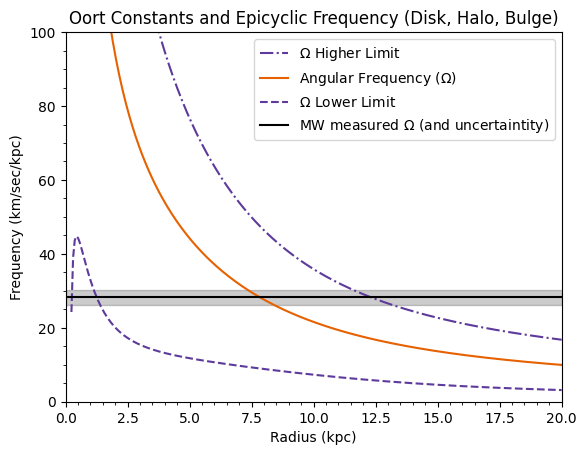

: 

In [ ]:
# Angular velocity
Omega = V_tot_with_bulge / R_prob3   # km/s/kpc

# Epicyclic frequency
dVdR = np.gradient(V_tot_with_bulge, R_prob3)

A = -0.5 * (dVdR - Omega)
B = -0.5 * (dVdR + Omega)
kappa = np.sqrt(-4*B*(A-B))

# Lindblad combinations
Omega_minus_kappa2 = Omega - kappa/2
Omega_plus_kappa2 = Omega + kappa/2

# Milky Way spiral pattern speed
Omega_p = 28.2  # km/s/kpc

# Plot

plt.plot(R_prob3, Omega_plus_kappa2, label = r"$\Omega$ Higher Limit", color = '#5D3A9B', ls = '-.')
plt.plot(R_prob3, Omega, label = r"Angular Frequency ($\Omega$)", color = '#E66100', ls = '-')
plt.plot(R_prob3, Omega_minus_kappa2, label = r"$\Omega$ Lower Limit", color = '#5D3A9B', ls = '--')
plt.axhline(28.2, color = 'k', label = r"MW measured $\Omega$ (and uncertaintity)")
plt.axhspan(28.2-2.1, 28.2+2.1, color='k', alpha=0.2)
plt.ylim(0,100)
plt.xlim(0,20)
plt.xlabel("Radius (kpc)")
plt.ylabel("Frequency (km/sec/kpc)")
plt.title("Oort Constants and Epicyclic Frequency (Disk, Halo, Bulge)")
plt.minorticks_on()
plt.legend()




In [87]:
from scipy.interpolate import interp1d

def find_radius(Omega_curve, Omega_p, R):
    """Find radius where Omega_curve crosses Omega_p."""
    f = interp1d(Omega_curve - Omega_p, R, kind='linear', fill_value='extrapolate')
    try:
        return f(0)
    except:
        return np.nan

# Corotation radius (CR)
R_CR = find_radius(Omega, Omega_p, R_prob3)

# Inner Lindblad Resonance (ILR)
R_ILR = find_radius(Omega_minus_kappa2, Omega_p, R_prob3)

# Outer Lindblad Resonance (OLR)
R_OLR = find_radius(Omega_plus_kappa2, Omega_p, R_prob3)

print(f"ILR: {R_ILR:.2f} kpc")
print(f"Corotation: {R_CR:.2f} kpc")
print(f"OLR: {R_OLR:.2f} kpc")

ILR: 1.26 kpc
Corotation: 7.84 kpc
OLR: 12.33 kpc


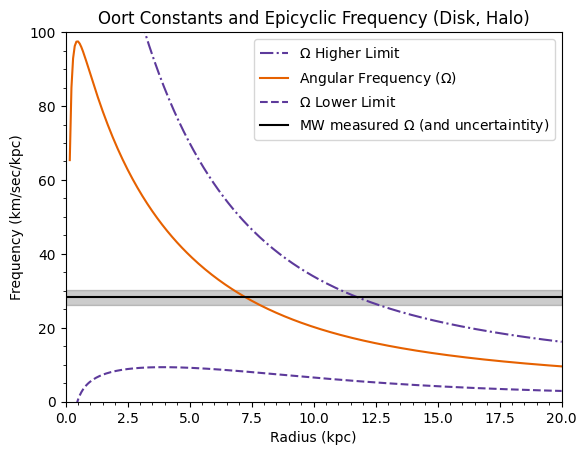

In [88]:
# Angular velocity
Omega = V_tot_no_bulge / R_prob3   # km/s/kpc

# Epicyclic frequency
dVdR = np.gradient(V_tot_no_bulge, R_prob3)
kappa_disk_halo = np.sqrt(2 * (V_tot_no_bulge / R_prob3) * (dVdR + V_tot_no_bulge / R_prob3))

# Lindblad combinations
Omega_minus_kappa2 = Omega - kappa_disk_halo/2
Omega_plus_kappa2 = Omega + kappa_disk_halo/2

# Milky Way spiral pattern speed
Omega_p = 28.2  # km/s/kpc

# Plot

plt.plot(R_prob3, Omega_plus_kappa2, label = r"$\Omega$ Higher Limit", color = '#5D3A9B', ls = '-.')
plt.plot(R_prob3, Omega, label = r"Angular Frequency ($\Omega$)", color = '#E66100', ls = '-')
plt.plot(R_prob3, Omega_minus_kappa2, label = r"$\Omega$ Lower Limit", color = '#5D3A9B', ls = '--')
plt.axhline(28.2, color = 'k', label = r"MW measured $\Omega$ (and uncertaintity)")
plt.axhspan(28.2-2.1, 28.2+2.1, color='k', alpha=0.2)
plt.ylim(0,100)
plt.xlim(0,20)
plt.xlabel("Radius (kpc)")
plt.ylabel("Frequency (km/sec/kpc)")
plt.title("Oort Constants and Epicyclic Frequency (Disk, Halo)")
plt.minorticks_on()
plt.legend()

In [89]:
from scipy.interpolate import interp1d

def find_radius(Omega_curve, Omega_p, R):
    """Find radius where Omega_curve crosses Omega_p."""
    f = interp1d(Omega_curve - Omega_p, R, kind='linear', fill_value='extrapolate')
    try:
        return f(0)
    except:
        return np.nan

# Corotation radius (CR)
R_CR = find_radius(Omega, Omega_p, R_prob3)

# Inner Lindblad Resonance (ILR)
R_ILR = find_radius(Omega_minus_kappa2, Omega_p, R_prob3)

# Outer Lindblad Resonance (OLR)
R_OLR = find_radius(Omega_plus_kappa2, Omega_p, R_prob3)

print(f"ILR: {R_ILR:.2f} kpc")
print(f"Corotation: {R_CR:.2f} kpc")
print(f"OLR: {R_OLR:.2f} kpc")


ILR: nan kpc
Corotation: 7.27 kpc
OLR: 11.79 kpc


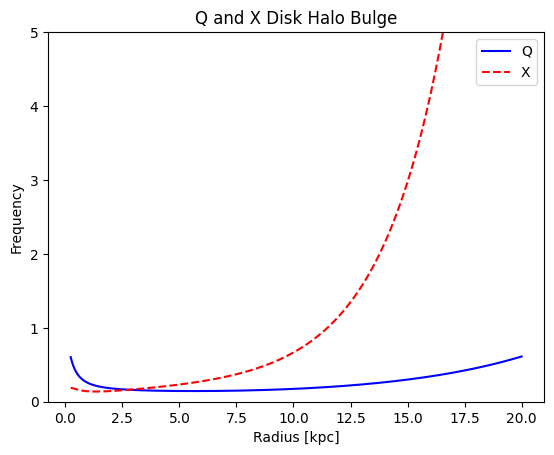

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
G = 4.43e-6  # km^2/s^2 pc / Msun

# Galaxy parameters
R_pc = R_prob3 * 1000       # Convert R to pc
R_d_pc = 2.5 * 1000         # Disk scale length in pc
Sigma0 = 1.2e3                 # Msun/pc^2
Sigma_sun = 50               # Msun/pc^2 at solar radius

# Disk surface density
Sigma = Sigma0 * np.exp(-R_pc / R_d_pc)  # Msun/pc^2

# Radial velocity dispersion
sigma_R = 30 * np.sqrt(Sigma / Sigma_sun)  # km/s

# Kappa values for each model (make sure these match R_prob3)
# Example placeholders; replace with your actual kappa arrays

# Convert kappa to km/s/pc
kappa_pc_bulge = kappa / 1000
kappa_pc_no_bulge = kappa_disk_halo / 1000

# Toomre Q
Q_bulge = (sigma_R * kappa_pc_bulge) / (3.36 * G * Sigma)
Q_no_bulge = (sigma_R * kappa_pc_no_bulge) / (3.36 * G * Sigma)

# X-bar
X_bulge = (kappa_pc_bulge**2 * R_pc) / (4 * np.pi * G * Sigma)
X_no_bulge = (kappa_pc_no_bulge**2 * R_pc) / (4 * np.pi * G * Sigma)


plt.plot(R_prob3, Q_bulge/10000, label='Q', color='blue')
plt.plot(R_prob3, X_bulge/10000, label='X', color='red',linestyle='--')
plt.ylim(0,5)
plt.xlabel('Radius [kpc]')
plt.ylabel('Frequency')
plt.title('Q and X Disk Halo Bulge')
plt.legend()



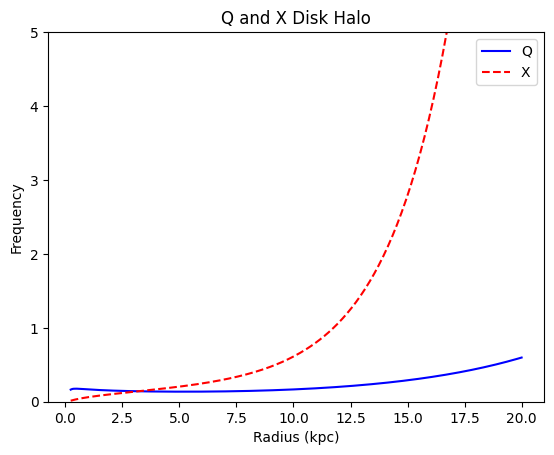

In [91]:
# X-bar
plt.plot(R_prob3, Q_no_bulge/10000, label='Q', color='blue')
plt.plot(R_prob3, X_no_bulge/10000, label='X', color='red', linestyle='--')
plt.ylim(0,5)
plt.xlabel('Radius (kpc)')
plt.ylabel('Frequency')
plt.title('Q and X Disk Halo')
plt.legend()
plt.show()